# Step 8-B: 분석용 XAI

**포함 모듈**
- 8-B1 분기별 수익·하방위험 시계열
- 8-B2 BL 내재수익률(Π) vs 실현수익률 산포도
- 8-B3 지역 제약 활성화 이력
- 8-B4 슬롯별 성과 기여도

> 운용역·연구자 대면 분석 자료. 모든 결과는 **투자 참고 정보**입니다.

## 환경 설정 & 공통 데이터 로드

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')

ROOT   = Path('..').resolve()
S5_DIR = ROOT / 'results' / 'step5'
S7_DIR = ROOT / 'results' / 'step7'

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']         = 110

SLOTS = [
    '국내주식_코스피', '국내주식_코스닥',
    '미국주식_SP500',  '미국주식_나스닥',
    '신흥국_인도',     '신흥국_중국',
    '국내채권_국고채단중기', '국내채권_국고채장기',
    '국내채권_회사채', '국내채권_종합',
    '해외채권_미국국채',
    '원자재_금',
    '무위험(현금성)',
]
RISKY_SLOTS = [s for s in SLOTS if s != '무위험(현금성)']

DISCLAIMER = '※ 투자 참고 정보입니다. 미래 수익을 보장하지 않으며, 투자 결정은 투자자 본인이 합니다.'

# ── 공통 데이터 로드 ──
perf_con  = pd.read_parquet(S5_DIR / 'portfolio_performance_constrained.parquet')
perf_mvp  = pd.read_parquet(S5_DIR / 'portfolio_performance_mvp.parquet')
w_con     = pd.read_parquet(S5_DIR / 'portfolio_weights_constrained.parquet')
w_mvp     = pd.read_parquet(S5_DIR / 'portfolio_weights_mvp.parquet')
bind_h    = pd.read_parquet(S5_DIR / 'binding_history.parquet')
pi_h      = pd.read_parquet(S5_DIR / 'pi_history.parquet')
idx_rets  = pd.read_parquet(ROOT / 'data' / 'index_returns.parquet').reindex(columns=SLOTS)

# 컬럼명 정렬 보장
w_con.columns = SLOTS
w_mvp.columns = SLOTS
pi_h.columns  = SLOTS

print(f'백테스트 분기: {len(perf_con)}개  ({perf_con.index.min().date()} ~ {perf_con.index.max().date()})')
print(f'index_returns: {idx_rets.index.min().date()} ~ {idx_rets.index.max().date()}')

백테스트 분기: 38개  (2016-01-29 ~ 2025-01-16)
index_returns: 2000-01-03 ~ 2025-04-30


---
## 8-B1 분기별 수익·하방위험 시계열

OOS 분기별 포트폴리오 수익률과 하방위험의 시간적 변화를 보여줍니다.  
- 위: 분기 OOS 수익률 바 (Sortino-max / MVP)
- 아래: 분기별 하방위험(%)

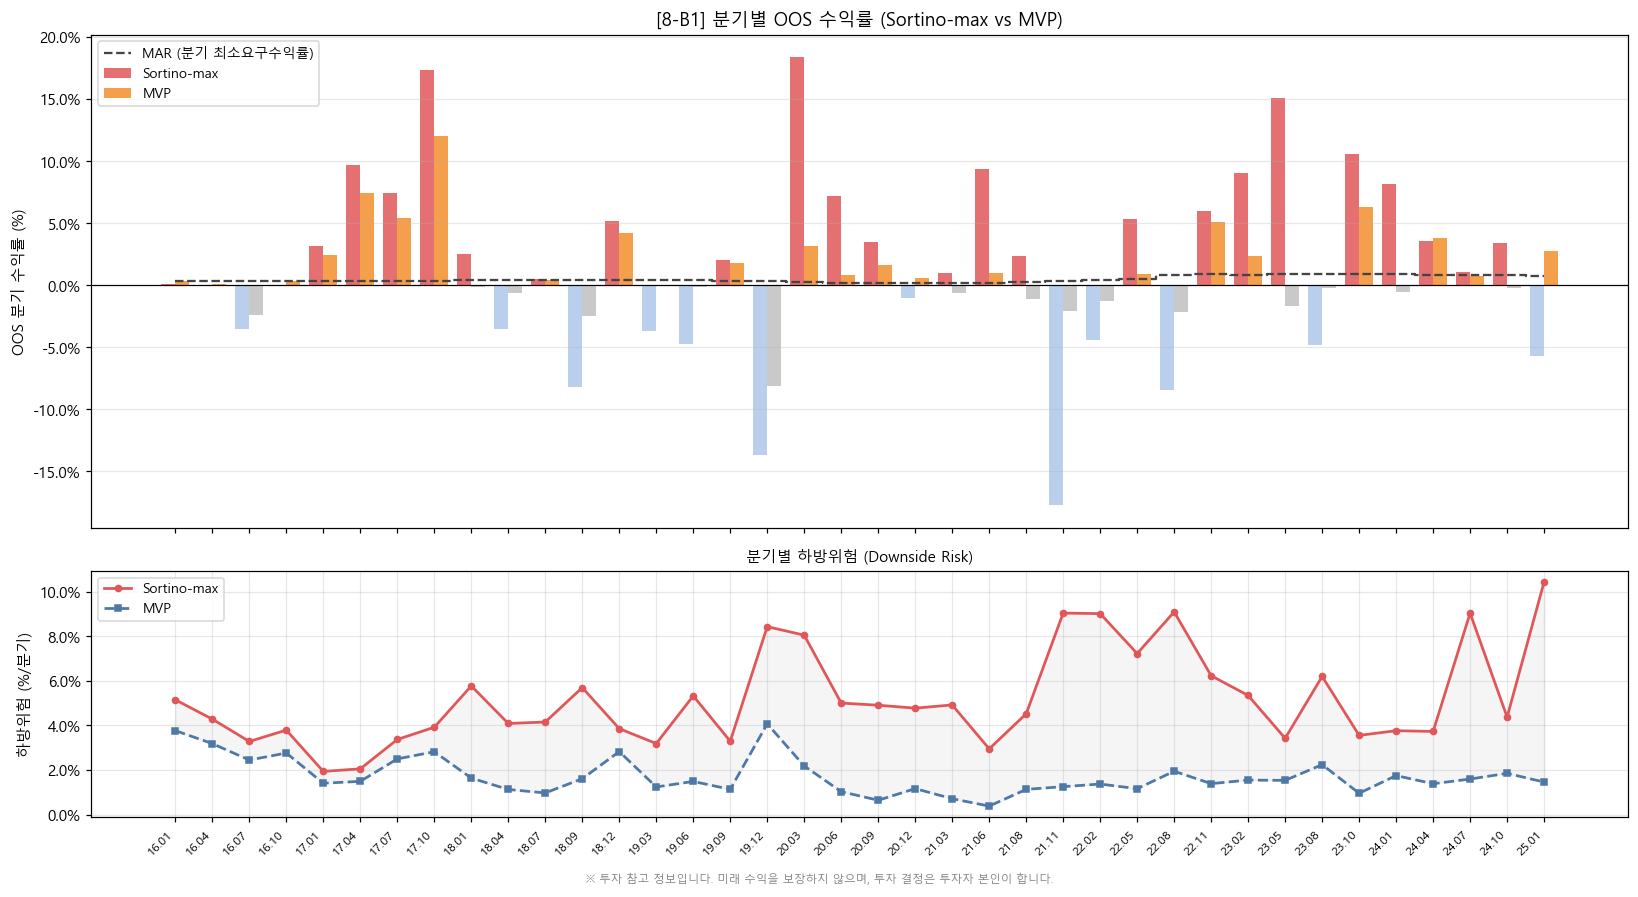

MAR 초과 분기: Sortino-max 23/38  (61%)
              MVP          20/38  (53%)
평균 하방위험: Sortino-max 5.19%  |  MVP 1.71%


In [2]:
dates = perf_con.index
x     = np.arange(len(dates))
xlbl  = [d.strftime('%y.%m') for d in dates]
W     = 0.38

con_ret = perf_con['cum_ret_pct'].values
mvp_ret = perf_mvp['cum_ret_pct'].values
con_dr  = perf_con['down_risk_pct'].values
mvp_dr  = perf_mvp['down_risk_pct'].values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# ── 분기 수익률 ──
b1 = ax1.bar(x - W/2, con_ret, W,
             color=['#e15759' if v >= 0 else '#aec7e8' for v in con_ret],
             alpha=0.85, label='Sortino-max')
b2 = ax1.bar(x + W/2, mvp_ret, W,
             color=['#f28e2b' if v >= 0 else '#c0c0c0' for v in mvp_ret],
             alpha=0.85, label='MVP')
ax1.axhline(0, color='black', lw=0.8)

# MAR 분기 수익률 오버레이
mar_q_pct = perf_con['mar_annual_pct'] / 4
ax1.step(x, mar_q_pct.values, where='mid', color='#444', lw=1.5,
         linestyle='--', label='MAR (분기 최소요구수익률)')

ax1.set_ylabel('OOS 분기 수익률 (%)')
ax1.set_title('[8-B1] 분기별 OOS 수익률 (Sortino-max vs MVP)', fontsize=12)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# ── 하방위험 ──
ax2.plot(x, con_dr, '-o', color='#e15759', ms=4, lw=1.8, label='Sortino-max')
ax2.plot(x, mvp_dr, '--s', color='#4e79a7', ms=4, lw=1.8, label='MVP')
ax2.fill_between(x, con_dr, mvp_dr, alpha=0.08, color='gray')
ax2.set_ylabel('하방위험 (%/분기)')
ax2.set_title('분기별 하방위험 (Downside Risk)', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

ax2.set_xticks(x)
ax2.set_xticklabels(xlbl, rotation=45, fontsize=8, ha='right')

fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

# 요약
n_beat_mar_con = (perf_con['cum_ret_pct'] >= mar_q_pct).sum()
n_beat_mar_mvp = (perf_mvp['cum_ret_pct'] >= mar_q_pct).sum()
n_total        = len(perf_con)
print(f'MAR 초과 분기: Sortino-max {n_beat_mar_con}/{n_total}  ({n_beat_mar_con/n_total*100:.0f}%)')
print(f'              MVP          {n_beat_mar_mvp}/{n_total}  ({n_beat_mar_mvp/n_total*100:.0f}%)')
print(f'평균 하방위험: Sortino-max {con_dr.mean():.2f}%  |  MVP {mvp_dr.mean():.2f}%')

---
## 8-B2 BL 내재수익률(Π) vs 실현수익률 산포도

각 분기마다 BL 모델이 예측한 내재수익률(Π, 분기 환산)과 실제 OOS 실현수익률을 슬롯별로 비교합니다.  
대각선 가까울수록 BL 예측이 정확함을 의미합니다.

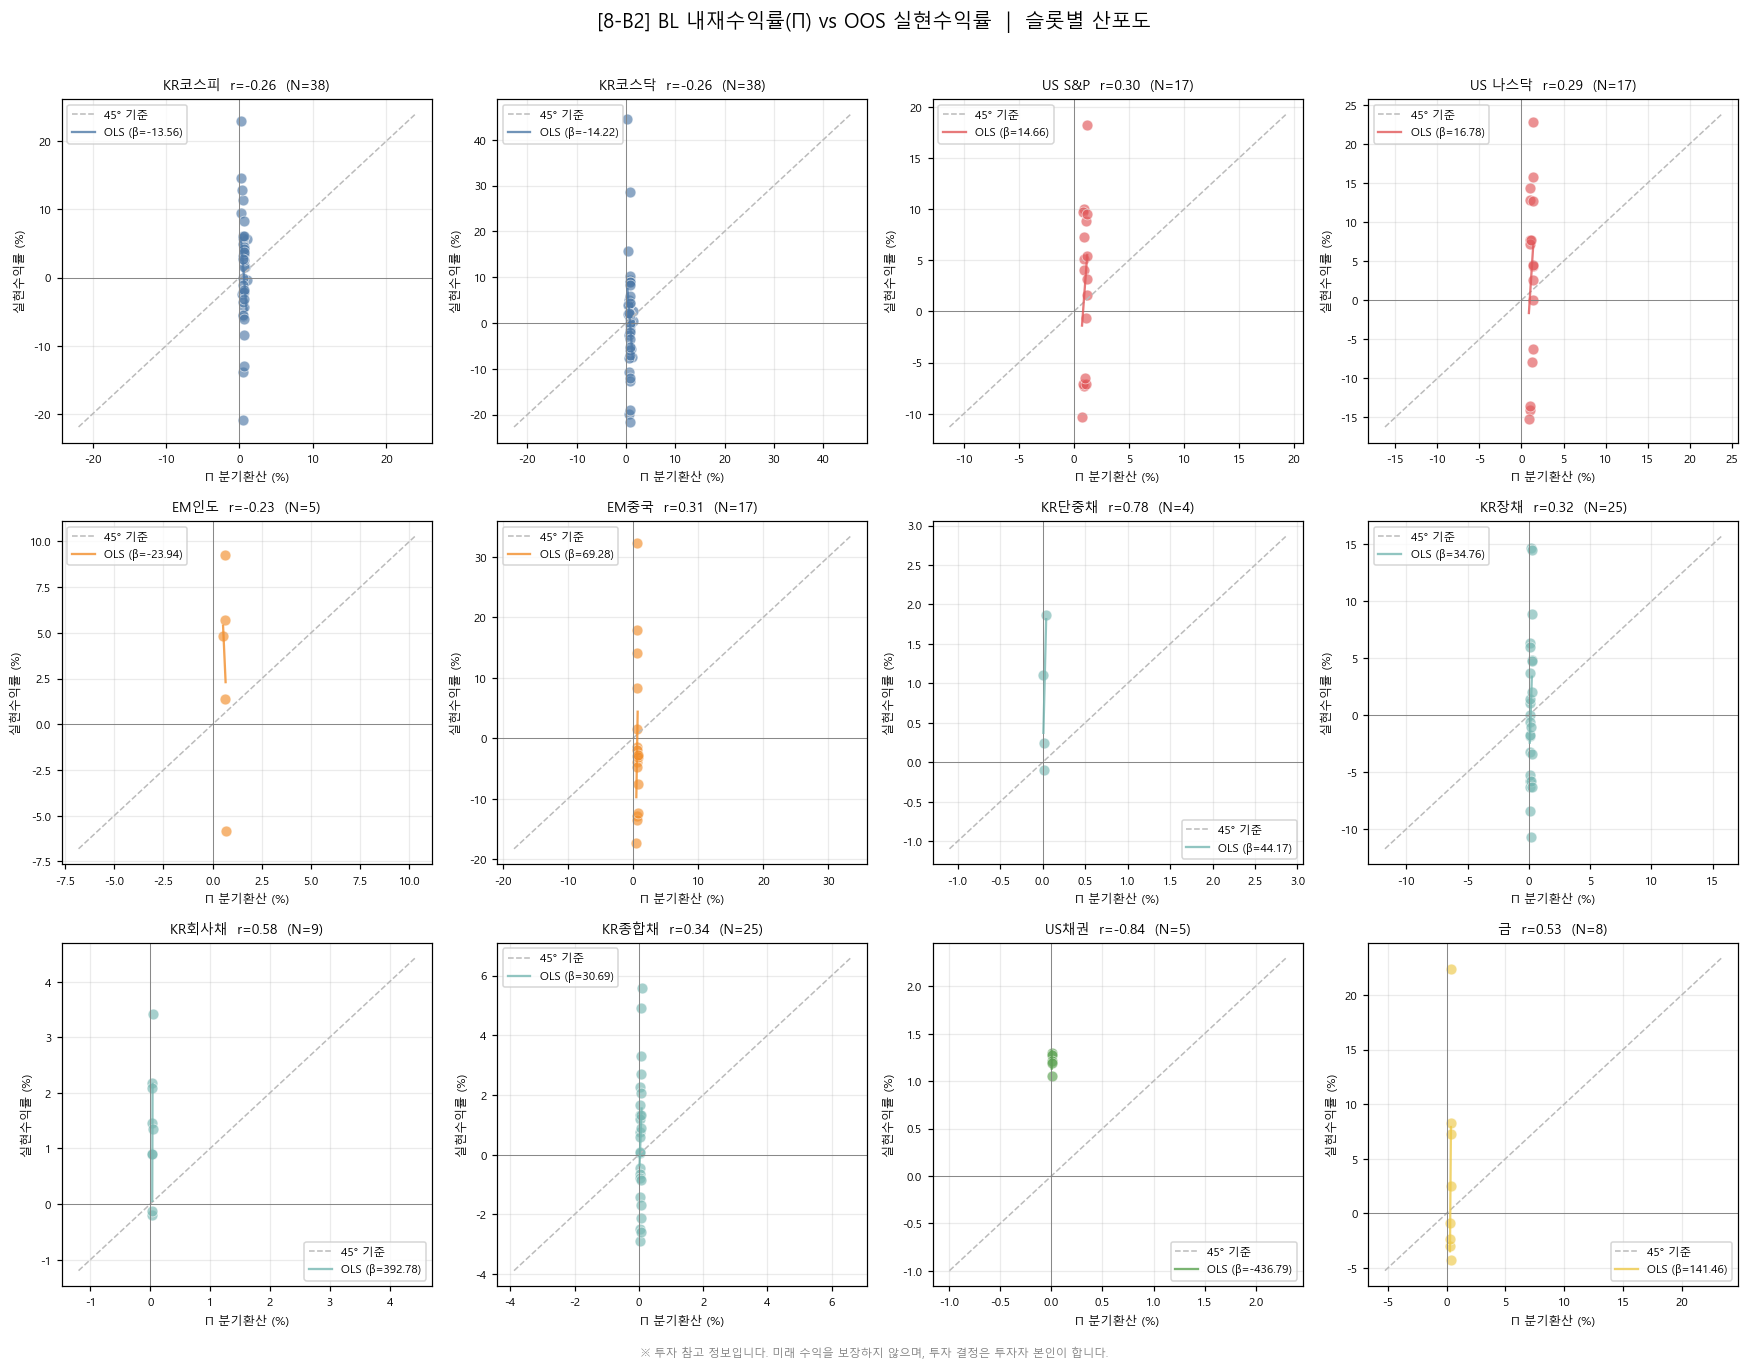

유효 슬롯: 12개 / 12개

슬롯별 Π–실현수익률 상관계수 (N: 유효 분기 수):
  KR코스피         N=38  r=-0.265  편의= +0.62%  RMSE=8.06%
  KR코스닥         N=38  r=-0.257  편의= -0.06%  RMSE=12.12%
  US S&P        N=17  r= 0.297  편의= +1.59%  RMSE=7.88%
  US 나스닥        N=17  r= 0.286  편의= +2.07%  RMSE=11.12%
  EM인도          N= 5  r=-0.227  편의= +2.45%  RMSE=5.67%
  EM중국          N=17  r= 0.313  편의= -1.22%  RMSE=12.32%
  KR단중채         N= 4  r= 0.784  편의= +0.76%  RMSE=1.07%
  KR장채          N=25  r= 0.323  편의= +0.16%  RMSE=6.42%
  KR회사채         N= 9  r= 0.576  편의= +1.29%  RMSE=1.69%
  KR종합채         N=25  r= 0.335  편의= +0.46%  RMSE=2.22%
  US채권          N= 5  r=-0.844  편의= +1.20%  RMSE=1.21%
  금             N= 8  r= 0.526  편의= +3.39%  RMSE=8.93%


In [3]:
REBAL_DAYS = 63

rebal_dates = perf_con.index.tolist()
slot_pi_realized = {s: [] for s in RISKY_SLOTS}

for i, d in enumerate(rebal_dates):
    end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else idx_rets.index[-1]
    oos = idx_rets.loc[d:end]
    if len(oos) < 2 or d not in pi_h.index:
        continue
    pi_row = pi_h.loc[d]

    for s in RISKY_SLOTS:
        if s not in oos.columns:
            continue
        pi_val = pi_row.get(s, np.nan)
        if np.isnan(pi_val):          # Π 추정 불가 분기 제외
            continue
        pi_q   = float(pi_val) * REBAL_DAYS * 100
        real_r = oos[s].dropna()
        if len(real_r) < 5:
            continue
        real_q = float((1 + real_r).prod() - 1) * 100
        slot_pi_realized[s].append((pi_q, real_q))

# ── 슬롯 그룹핑 ──
GROUP_COLOR = {
    '국내주식_코스피': '#4e79a7', '국내주식_코스닥': '#4e79a7',
    '미국주식_SP500': '#e15759',  '미국주식_나스닥': '#e15759',
    '신흥국_인도':    '#f28e2b',  '신흥국_중국':    '#f28e2b',
    '국내채권_국고채단중기': '#76b7b2', '국내채권_국고채장기': '#76b7b2',
    '국내채권_회사채': '#76b7b2',       '국내채권_종합': '#76b7b2',
    '해외채권_미국국채': '#59a14f',
    '원자재_금': '#edc948',
}
SHORT = {
    '국내주식_코스피':'KR코스피','국내주식_코스닥':'KR코스닥',
    '미국주식_SP500':'US S&P','미국주식_나스닥':'US 나스닥',
    '신흥국_인도':'EM인도','신흥국_중국':'EM중국',
    '국내채권_국고채단중기':'KR단중채','국내채권_국고채장기':'KR장채',
    '국내채권_회사채':'KR회사채','국내채권_종합':'KR종합채',
    '해외채권_미국국채':'US채권','원자재_금':'금',
}

# ── 산포도 (유효 슬롯만 표시) ──
valid_slots = [s for s in RISKY_SLOTS if len(slot_pi_realized[s]) >= 3]
ncols = 4
nrows = int(np.ceil(len(valid_slots) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes_flat = axes.flatten() if nrows > 1 else axes

for idx, s in enumerate(valid_slots):
    ax = axes_flat[idx]
    xs, ys = zip(*slot_pi_realized[s])
    xs, ys = np.array(xs), np.array(ys)
    n_pts  = len(xs)
    corr   = np.corrcoef(xs, ys)[0, 1] if n_pts > 2 else float('nan')

    ax.scatter(xs, ys, color=GROUP_COLOR.get(s, '#888'), alpha=0.65, s=50,
               edgecolors='white', lw=0.5)

    lims = [min(xs.min(), ys.min()) - 1, max(xs.max(), ys.max()) + 1]
    ax.plot(lims, lims, '--', color='#bbb', lw=1, label='45° 기준')
    ax.axhline(0, color='gray', lw=0.6)
    ax.axvline(0, color='gray', lw=0.6)

    if n_pts > 2 and xs.std() > 1e-6:
        try:
            m, b = np.polyfit(xs, ys, 1)
            xfit = np.linspace(xs.min(), xs.max(), 50)
            ax.plot(xfit, m * xfit + b, '-', color=GROUP_COLOR.get(s, '#888'),
                    lw=1.5, alpha=0.8, label=f'OLS (β={m:.2f})')
            ax.legend(fontsize=7.5)
        except np.linalg.LinAlgError:
            pass

    ax.set_title(f'{SHORT.get(s, s)}  r={corr:.2f}  (N={n_pts})', fontsize=9)
    ax.set_xlabel('Π 분기환산 (%)', fontsize=8)
    ax.set_ylabel('실현수익률 (%)', fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.grid(alpha=0.25)

# 남는 서브플롯 숨기기
for idx in range(len(valid_slots), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('[8-B2] BL 내재수익률(Π) vs OOS 실현수익률  |  슬롯별 산포도', fontsize=13, y=1.01)
fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

print(f'유효 슬롯: {len(valid_slots)}개 / {len(RISKY_SLOTS)}개')
print(f'\n슬롯별 Π–실현수익률 상관계수 (N: 유효 분기 수):')
for s in valid_slots:
    xs, ys = zip(*slot_pi_realized[s])
    xs, ys = np.array(xs), np.array(ys)
    r    = np.corrcoef(xs, ys)[0, 1]
    bias = ys.mean() - xs.mean()
    rmse = np.sqrt(((ys - xs)**2).mean())
    print(f'  {SHORT.get(s,s):<12}  N={len(xs):>2}  r={r:>6.3f}  편의={bias:>+6.2f}%  RMSE={rmse:.2f}%')

---
## 8-B3 지역 제약 활성화 이력

US≤50%, KR≤50%, EM≤15% 제약이 실제로 binding된 분기를 시각화합니다.  
제약이 활성화된 시기는 시장 쏠림(모멘텀)이 특정 지역에 집중됐음을 의미합니다.

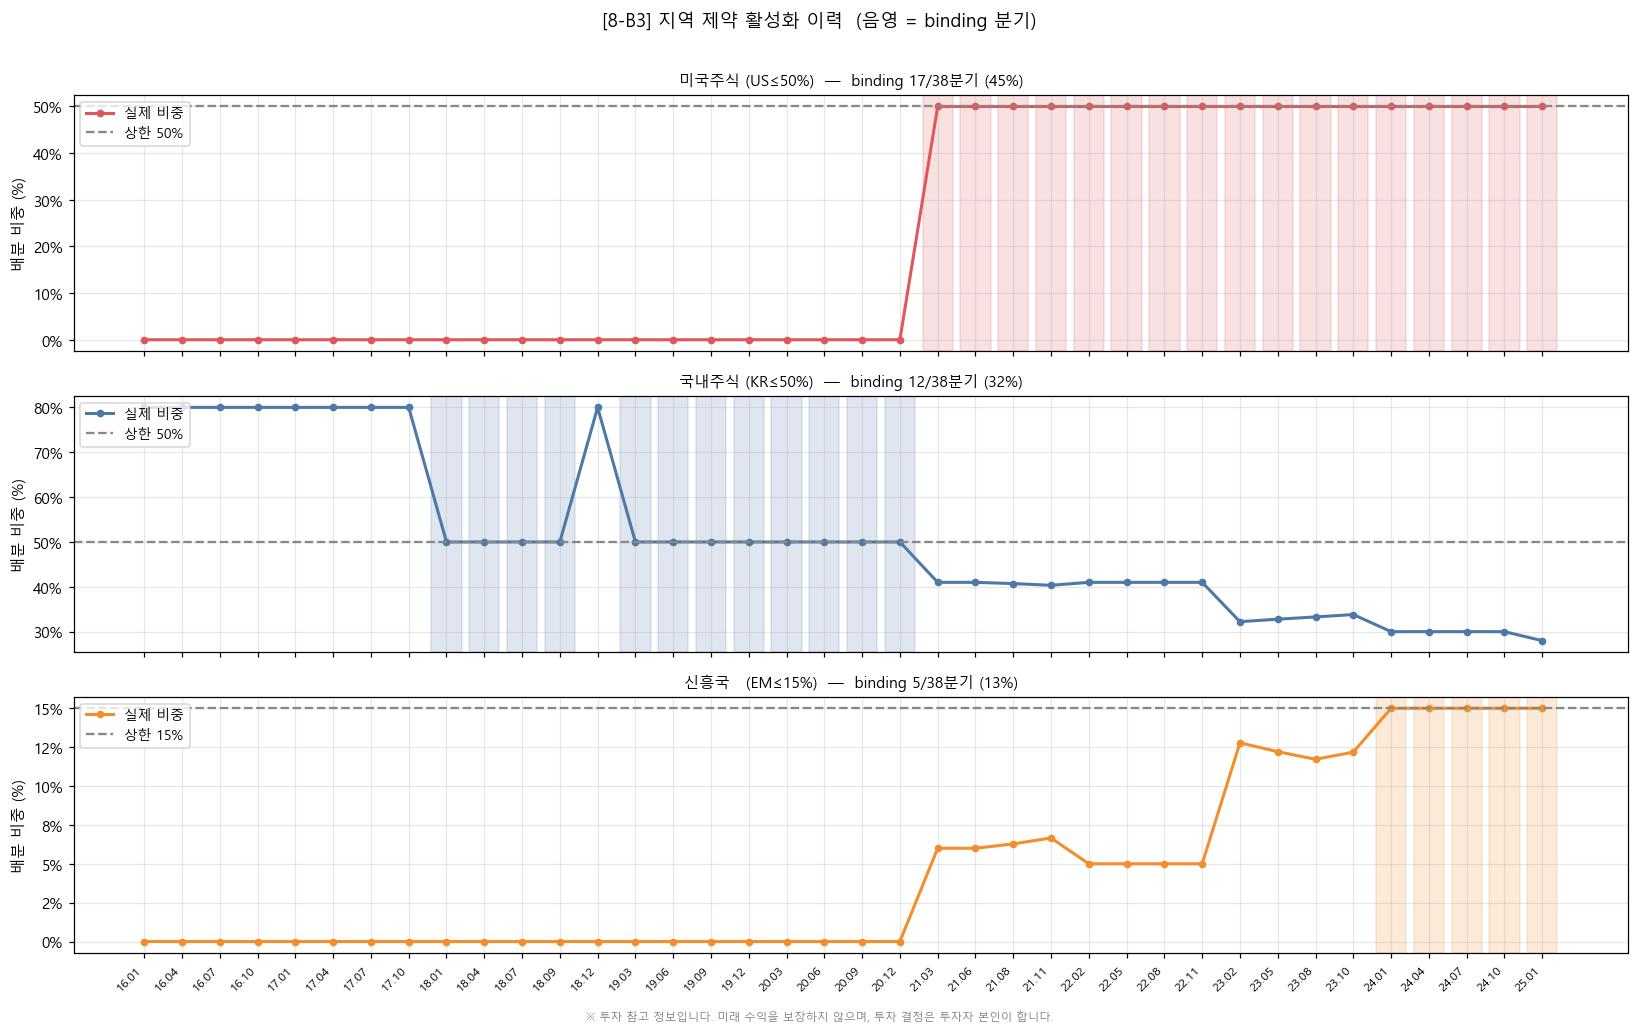


제약 비용 (제약 있을 때 소르티노 손실):
  binding 분기 평균 제약비용: 0.4307
  free    분기 평균 제약비용: 0.0000
  전체 binding 비율: US 45%  KR 32%  EM 13%


In [4]:
dates_b = bind_h.index
x_b     = np.arange(len(dates_b))
xlbl_b  = [d.strftime('%y.%m') for d in dates_b]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

REGION_META = [
    ('us',  '미국주식 (US≤50%)',  '#e15759', 0.50),
    ('kr',  '국내주식 (KR≤50%)',  '#4e79a7', 0.50),
    ('em',  '신흥국   (EM≤15%)',  '#f28e2b', 0.15),
]

for ax, (key, label, color, cap) in zip(axes, REGION_META):
    alloc   = bind_h[f'{key}_alloc'].values * 100
    binding = bind_h[f'{key}_binding'].values

    # 실제 비중 라인
    ax.plot(x_b, alloc, '-o', color=color, ms=4, lw=2, label=f'실제 비중')
    ax.axhline(cap * 100, ls='--', color='#888', lw=1.5, label=f'상한 {cap*100:.0f}%')

    # binding 구간 음영
    for i, is_bind in enumerate(binding):
        if is_bind:
            ax.axvspan(i - 0.4, i + 0.4, color=color, alpha=0.18)

    n_bind = binding.sum()
    ax.set_ylabel('배분 비중 (%)')
    ax.set_title(f'{label}  —  binding {n_bind}/{len(dates_b)}분기 ({n_bind/len(dates_b)*100:.0f}%)',
                 fontsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

axes[-1].set_xticks(x_b)
axes[-1].set_xticklabels(xlbl_b, rotation=45, fontsize=8, ha='right')

fig.suptitle('[8-B3] 지역 제약 활성화 이력  (음영 = binding 분기)', fontsize=12, y=1.01)
fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

# 제약 비용 분석
print('\n제약 비용 (제약 있을 때 소르티노 손실):')  
cost = bind_h['constraint_cost']
bind_any = bind_h[['us_binding','kr_binding','em_binding']].any(axis=1)
print(f'  binding 분기 평균 제약비용: {cost[bind_any].mean():.4f}')
print(f'  free    분기 평균 제약비용: {cost[~bind_any].mean():.4f}')
print(f'  전체 binding 비율: US {bind_h["us_binding"].mean()*100:.0f}%  KR {bind_h["kr_binding"].mean()*100:.0f}%  EM {bind_h["em_binding"].mean()*100:.0f}%')

---
## 8-B4 슬롯별 성과 기여도

각 분기 OOS 수익률을 슬롯별로 분해합니다 (비중 × OOS 수익률).  
누적 기여도로 어떤 자산군이 장기 성과를 이끌었는지 파악합니다.

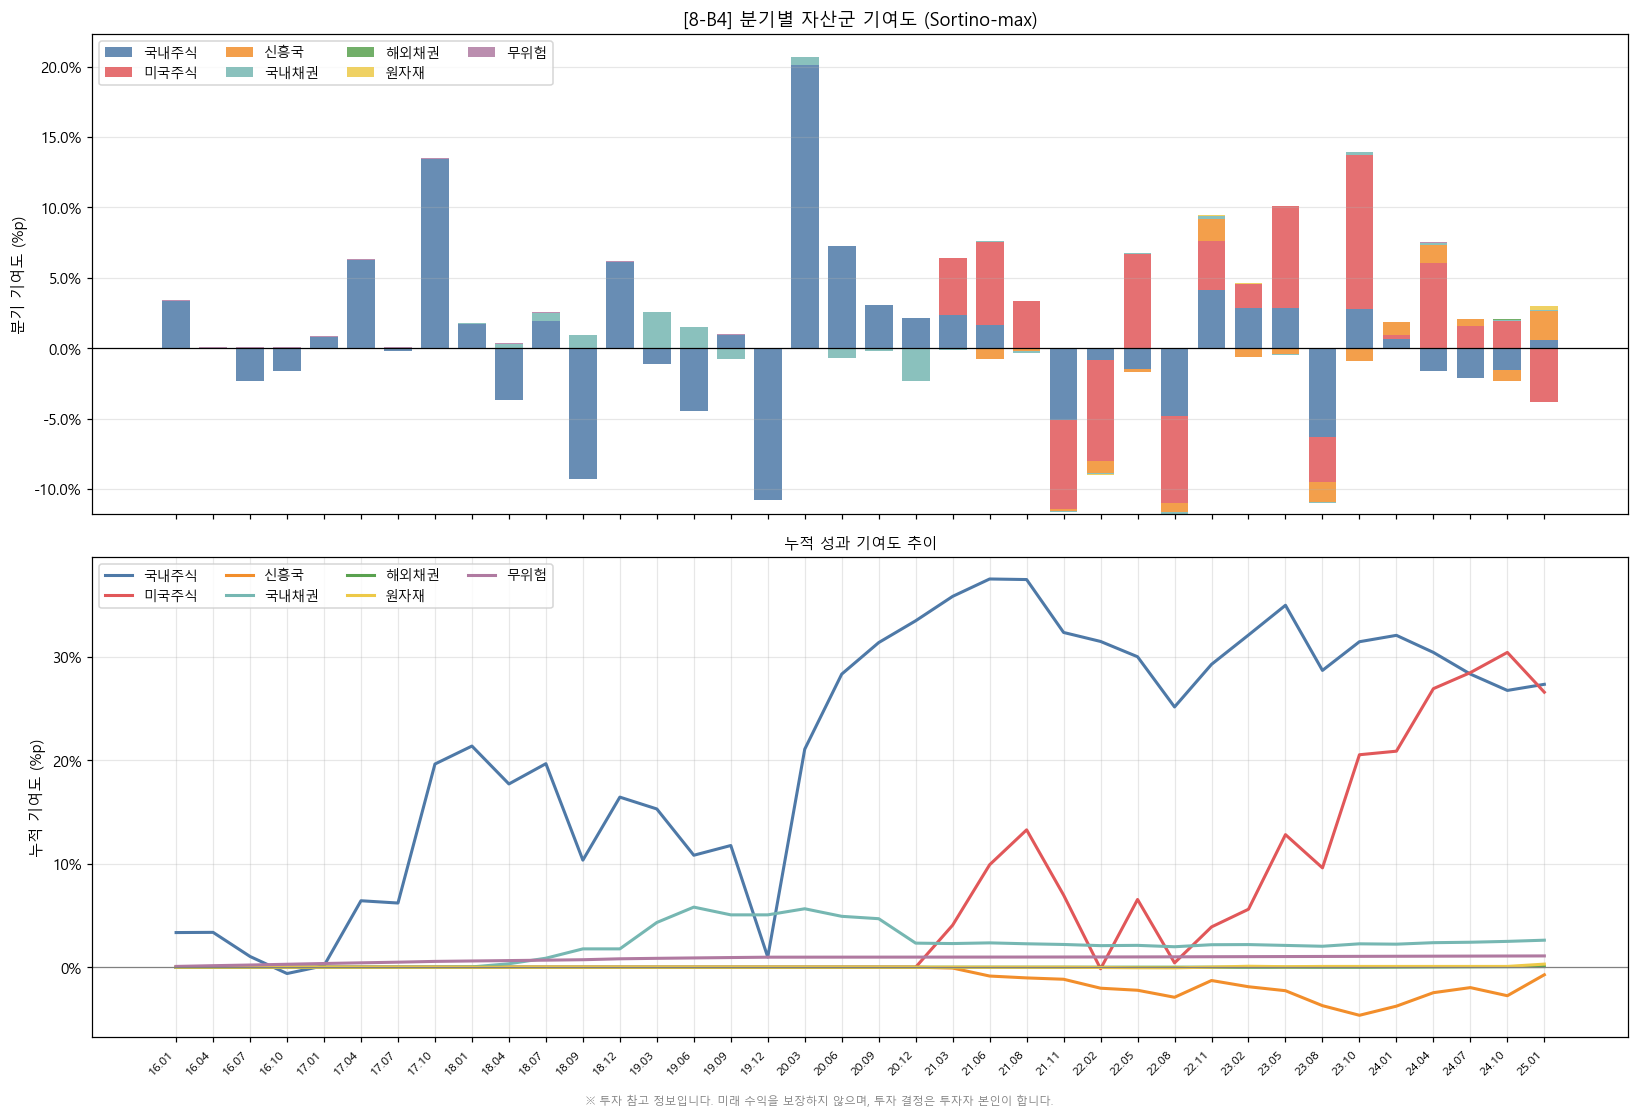


전체 기간 누적 기여도 순위 (Sortino-max):
  국내주식      + 27.32%p  ████████████████████
  미국주식      + 26.56%p  ███████████████████
  국내채권      +  2.61%p  █
  무위험       +  1.09%p  
  원자재       +  0.30%p  
  해외채권      +  0.06%p  
  신흥국        -0.73%p  
  합계        +57.20%p


In [5]:
GROUP_MAP = {
    '국내주식_코스피': '국내주식', '국내주식_코스닥': '국내주식',
    '미국주식_SP500':  '미국주식', '미국주식_나스닥':  '미국주식',
    '신흥국_인도':     '신흥국',   '신흥국_중국':     '신흥국',
    '국내채권_국고채단중기': '국내채권', '국내채권_국고채장기': '국내채권',
    '국내채권_회사채': '국내채권', '국내채권_종합': '국내채권',
    '해외채권_미국국채': '해외채권',
    '원자재_금': '원자재',
    '무위험(현금성)': '무위험',
}
GROUPS    = ['국내주식','미국주식','신흥국','국내채권','해외채권','원자재','무위험']
GRP_COLOR = ['#4e79a7','#e15759','#f28e2b','#76b7b2','#59a14f','#edc948','#b07aa1']

rebal_dates = w_con.index.tolist()
contrib_rows = []

for i, d in enumerate(rebal_dates):
    end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else idx_rets.index[-1]
    oos = idx_rets.loc[d:end]
    if len(oos) < 2:
        continue

    w_row = w_con.loc[d]  # 슬롯별 비중
    row   = {'date': d}
    for s in SLOTS:
        ret_s  = oos[s].dropna()
        real_q = float((1 + ret_s).prod() - 1) if len(ret_s) > 0 else 0.0
        row[s] = float(w_row.get(s, 0)) * real_q * 100  # 기여도 (%)
    contrib_rows.append(row)

contrib_df = pd.DataFrame(contrib_rows).set_index('date')

# 그룹별 집계
grp_contrib = pd.DataFrame(index=contrib_df.index)
for g in GROUPS:
    slots_g = [s for s in SLOTS if GROUP_MAP[s] == g]
    grp_contrib[g] = contrib_df[slots_g].sum(axis=1)

cum_grp = grp_contrib.cumsum()
x_c     = np.arange(len(grp_contrib))
xlbl_c  = [d.strftime('%y.%m') for d in grp_contrib.index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# ── 분기 기여도 누적 바 ──
bottoms_pos = np.zeros(len(x_c))
bottoms_neg = np.zeros(len(x_c))
for g, clr in zip(GROUPS, GRP_COLOR):
    vals = grp_contrib[g].values
    pos  = np.where(vals >= 0, vals, 0)
    neg  = np.where(vals <  0, vals, 0)
    ax1.bar(x_c, pos, bottom=bottoms_pos, color=clr, alpha=0.85, label=g, width=0.75)
    ax1.bar(x_c, neg, bottom=bottoms_neg, color=clr, alpha=0.85, width=0.75)
    bottoms_pos += pos
    bottoms_neg += neg

ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel('분기 기여도 (%p)')
ax1.set_title('[8-B4] 분기별 자산군 기여도 (Sortino-max)', fontsize=12)
ax1.legend(fontsize=9, loc='upper left', ncol=4)
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))

# ── 누적 기여도 라인 ──
for g, clr in zip(GROUPS, GRP_COLOR):
    ax2.plot(x_c, cum_grp[g].values, '-', color=clr, lw=2, label=g)
ax2.axhline(0, color='gray', lw=0.8)
ax2.set_ylabel('누적 기여도 (%p)')
ax2.set_title('누적 성과 기여도 추이', fontsize=10)
ax2.legend(fontsize=9, loc='upper left', ncol=4)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

ax2.set_xticks(x_c)
ax2.set_xticklabels(xlbl_c, rotation=45, fontsize=8, ha='right')

fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

# 전체 누적 기여도 순위
total_contrib = grp_contrib.sum().sort_values(ascending=False)
total_all     = total_contrib.sum()
print('\n전체 기간 누적 기여도 순위 (Sortino-max):')
for g, v in total_contrib.items():
    bar = '█' * int(abs(v) / max(abs(total_contrib)) * 20)
    sign = '+' if v >= 0 else ''
    print(f'  {g:<8}  {sign}{v:>6.2f}%p  {bar}')
print(f'  {'합계':<8}  {total_all:>+6.2f}%p')

---
## Step5b 비교: 모멘텀 뷰 추가 전후

`results/step5b/` (모멘텀 필터 B+C — 음(-)모멘텀 슬롯 제외 + AUM×모멘텀 w_mkt 재조정)와 원본 Step5를 비교합니다.
- **8-C1** 누적수익률 및 분기수익률 직접 비교
- **8-C2** μ_BL vs Π prior 산포도 (뷰 조정 효과)
- **8-C3** 성과 기여도 변화

In [6]:
S5B_DIR = ROOT / 'results' / 'step5b'

perf_5b  = pd.read_parquet(S5B_DIR / 'portfolio_performance_constrained.parquet')
w_5b     = pd.read_parquet(S5B_DIR / 'portfolio_weights_constrained.parquet')
pi_bl    = pd.read_parquet(S5B_DIR / 'pi_history.parquet')
pi_prior = pd.read_parquet(S5B_DIR / 'pi_prior_history.parquet')

w_5b.columns  = SLOTS
pi_bl.columns = SLOTS
pi_prior.columns = SLOTS

cum_5  = (1 + perf_con['cum_ret_pct'] / 100).cumprod()
cum_5b = (1 + perf_5b['cum_ret_pct'] / 100).cumprod()

print(f"Step5  : 누적 {(cum_5.iloc[-1]-1)*100:.1f}%  소르티노 {perf_con['sortino'].mean():.3f}  "
      f"MDD {((cum_5-cum_5.cummax())/cum_5.cummax()).min()*100:.1f}%")
print(f"Step5b : 누적 {(cum_5b.iloc[-1]-1)*100:.1f}%  소르티노 {perf_5b['sortino'].mean():.3f}  "
      f"MDD {((cum_5b-cum_5b.cummax())/cum_5b.cummax()).min()*100:.1f}%")

Step5  : 누적 84.0%  소르티노 0.599  MDD -24.3%
Step5b : 누적 83.4%  소르티노 0.659  MDD -23.7%


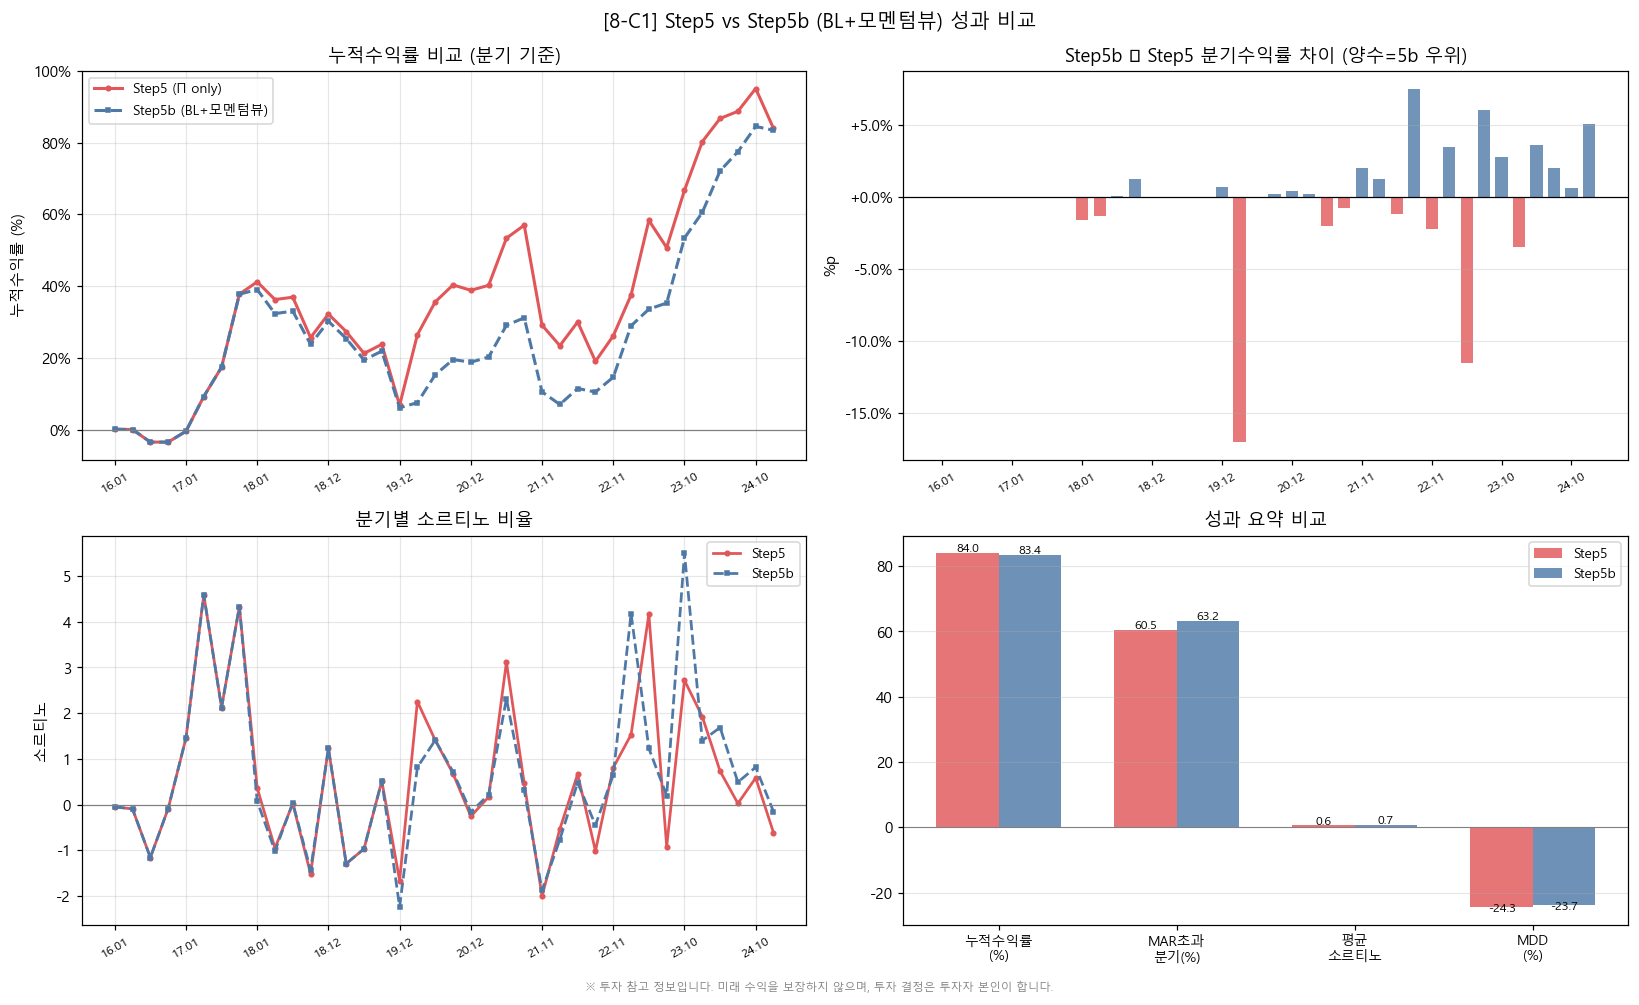

In [7]:
# ── 8-C1: 누적수익률 & 분기수익률 비교 ──
x_q   = np.arange(len(perf_con))
xlbl_q = [d.strftime('%y.%m') for d in perf_con.index]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 누적수익률 라인
ax = axes[0, 0]
ax.plot(x_q, (cum_5  - 1) * 100, '-o',  color='#e15759', ms=3, lw=2, label='Step5 (Π only)')
ax.plot(x_q, (cum_5b - 1) * 100, '--s', color='#4e79a7', ms=3, lw=2, label='Step5b (BL+모멘텀뷰)')
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('누적수익률 비교 (분기 기준)')
ax.set_ylabel('누적수익률 (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xticks(x_q[::4]); ax.set_xticklabels(xlbl_q[::4], rotation=30, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

# 분기수익률 차이
ax2 = axes[0, 1]
diff_ret = perf_5b['cum_ret_pct'].values - perf_con['cum_ret_pct'].values
colors_d = ['#4e79a7' if v >= 0 else '#e15759' for v in diff_ret]
ax2.bar(x_q, diff_ret, color=colors_d, alpha=0.8, width=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Step5b − Step5 분기수익률 차이 (양수=5b 우위)')
ax2.set_ylabel('%p')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticks(x_q[::4]); ax2.set_xticklabels(xlbl_q[::4], rotation=30, fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:+.1f}%'))

# 소르티노 비교
ax3 = axes[1, 0]
ax3.plot(x_q, perf_con['sortino'].values,  '-o',  color='#e15759', ms=3, lw=1.8, label='Step5')
ax3.plot(x_q, perf_5b['sortino'].values,   '--s', color='#4e79a7', ms=3, lw=1.8, label='Step5b')
ax3.axhline(0, color='gray', lw=0.8)
ax3.set_title('분기별 소르티노 비율')
ax3.set_ylabel('소르티노')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
ax3.set_xticks(x_q[::4]); ax3.set_xticklabels(xlbl_q[::4], rotation=30, fontsize=8)

# 성과 요약 바 차트
ax4 = axes[1, 1]
metrics  = ['누적수익률\n(%)', 'MAR초과\n분기(%)', '평균\n소르티노', 'MDD\n(%)']
mar_q    = perf_con['mar_annual_pct'] / 4
mar_q_5b = perf_5b['mar_annual_pct'] / 4
s5_vals  = [
    (cum_5.iloc[-1]  - 1) * 100,
    (perf_con['cum_ret_pct'] >= mar_q).mean()   * 100,
    perf_con['sortino'].mean(),
    ((cum_5  - cum_5.cummax())  / cum_5.cummax()).min()  * 100,
]
s5b_vals = [
    (cum_5b.iloc[-1] - 1) * 100,
    (perf_5b['cum_ret_pct'] >= mar_q_5b).mean() * 100,
    perf_5b['sortino'].mean(),
    ((cum_5b - cum_5b.cummax()) / cum_5b.cummax()).min() * 100,
]
xm = np.arange(len(metrics)); wm = 0.35
b1 = ax4.bar(xm - wm/2, s5_vals,  wm, label='Step5',  color='#e15759', alpha=0.82)
b2 = ax4.bar(xm + wm/2, s5b_vals, wm, label='Step5b', color='#4e79a7', alpha=0.82)
for bar in list(b1) + list(b2):
    v = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, v + (0.3 if v >= 0 else -1.5),
             f'{v:.1f}', ha='center', fontsize=8)
ax4.axhline(0, color='gray', lw=0.7)
ax4.set_xticks(xm); ax4.set_xticklabels(metrics, fontsize=9)
ax4.set_title('성과 요약 비교')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

fig.suptitle('[8-C1] Step5 vs Step5b (BL+모멘텀뷰) 성과 비교', fontsize=13)
fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

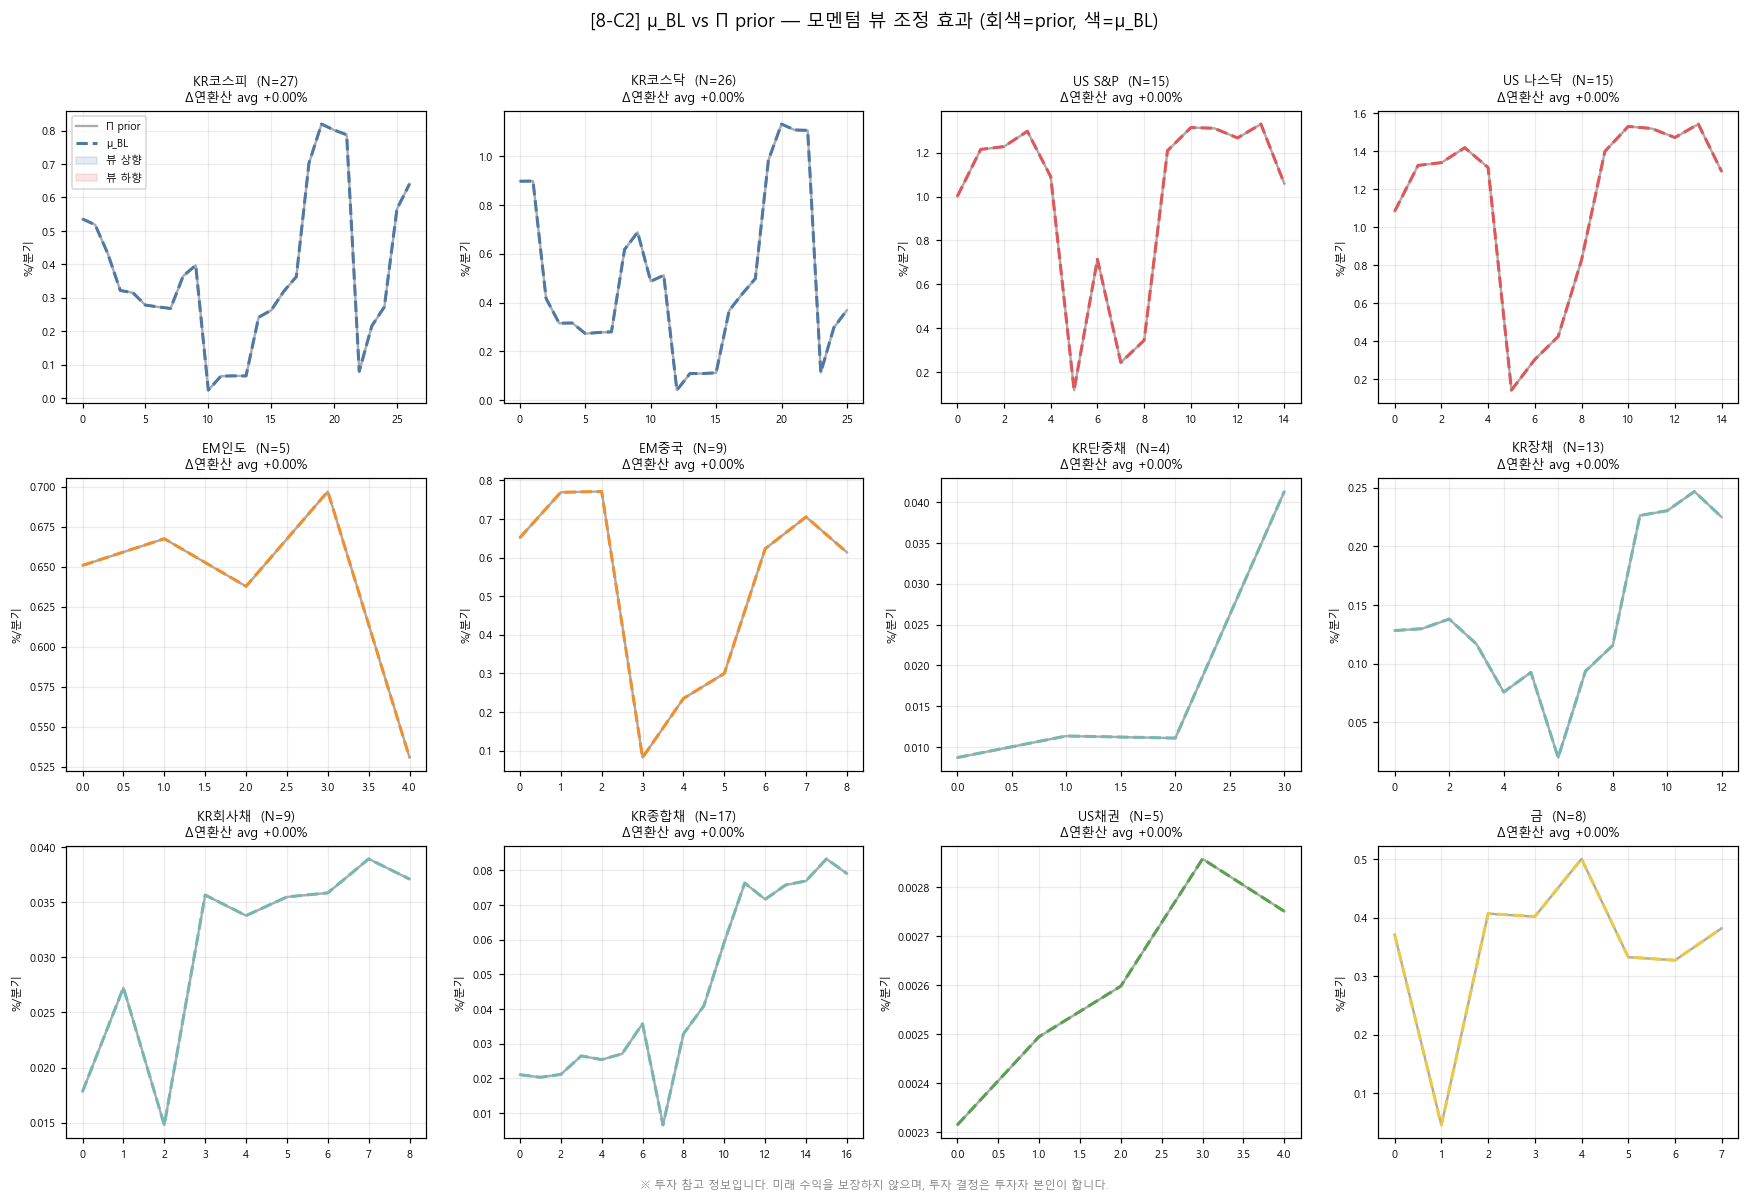

슬롯별 모멘텀 뷰 조정 방향 (연환산 평균):
  KR코스피         +0.000%/년  하향 ↓
  KR코스닥         +0.000%/년  하향 ↓
  US S&P        +0.000%/년  하향 ↓
  US 나스닥        +0.000%/년  하향 ↓
  EM인도          +0.000%/년  하향 ↓
  EM중국          +0.000%/년  하향 ↓
  KR단중채         +0.000%/년  하향 ↓
  KR장채          +0.000%/년  하향 ↓
  KR회사채         +0.000%/년  하향 ↓
  KR종합채         +0.000%/년  하향 ↓
  US채권          +0.000%/년  하향 ↓
  금             +0.000%/년  하향 ↓


In [8]:
# ── 8-C2: μ_BL vs Π prior 뷰 조정 효과 ──
# 슬롯별로 prior와 BL 조정 후 수익률을 겹쳐 보여줌
valid_bl_slots = [s for s in RISKY_SLOTS
                  if pi_bl[s].dropna().__len__() >= 3
                  and pi_prior[s].dropna().__len__() >= 3]

ncols = 4
nrows = int(np.ceil(len(valid_bl_slots) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes_flat = axes.flatten()

for idx, s in enumerate(valid_bl_slots):
    ax    = axes_flat[idx]
    dates = pi_bl.index[pi_bl[s].notna() & pi_prior[s].notna()]
    x_idx = np.arange(len(dates))
    pri   = pi_prior.loc[dates, s].values * REBAL_DAYS * 100
    bl_v  = pi_bl.loc[dates, s].values    * REBAL_DAYS * 100
    delta = bl_v - pri

    ax.plot(x_idx, pri,  '-',  color='#aaa',    lw=1.5, label='Π prior', zorder=2)
    ax.plot(x_idx, bl_v, '--', color=GROUP_COLOR.get(s, '#333'), lw=2, label='μ_BL', zorder=3)
    ax.fill_between(x_idx, pri, bl_v,
                    where=delta >= 0, alpha=0.15, color='#4e79a7', label='뷰 상향')
    ax.fill_between(x_idx, pri, bl_v,
                    where=delta <  0, alpha=0.15, color='#e15759', label='뷰 하향')

    mean_d = delta.mean() * 252 * 100  # 연환산
    ax.set_title(f'{SHORT.get(s,s)}  (N={len(dates)})\nΔ연환산 avg {mean_d:+.2f}%',
                 fontsize=8.5)
    ax.set_ylabel('%/분기', fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

for idx in range(len(valid_bl_slots), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('[8-C2] μ_BL vs Π prior — 모멘텀 뷰 조정 효과 (회색=prior, 색=μ_BL)',
             fontsize=12, y=1.01)
fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

# 뷰 조정 방향 요약
print('슬롯별 모멘텀 뷰 조정 방향 (연환산 평균):')
for s in valid_bl_slots:
    dates = pi_bl.index[pi_bl[s].notna() & pi_prior[s].notna()]
    delta_ann = (pi_bl.loc[dates, s] - pi_prior.loc[dates, s]).mean() * 252 * 100
    direction = '상향 ↑' if delta_ann > 0 else '하향 ↓'
    print(f'  {SHORT.get(s,s):<12}  {delta_ann:>+6.3f}%/년  {direction}')

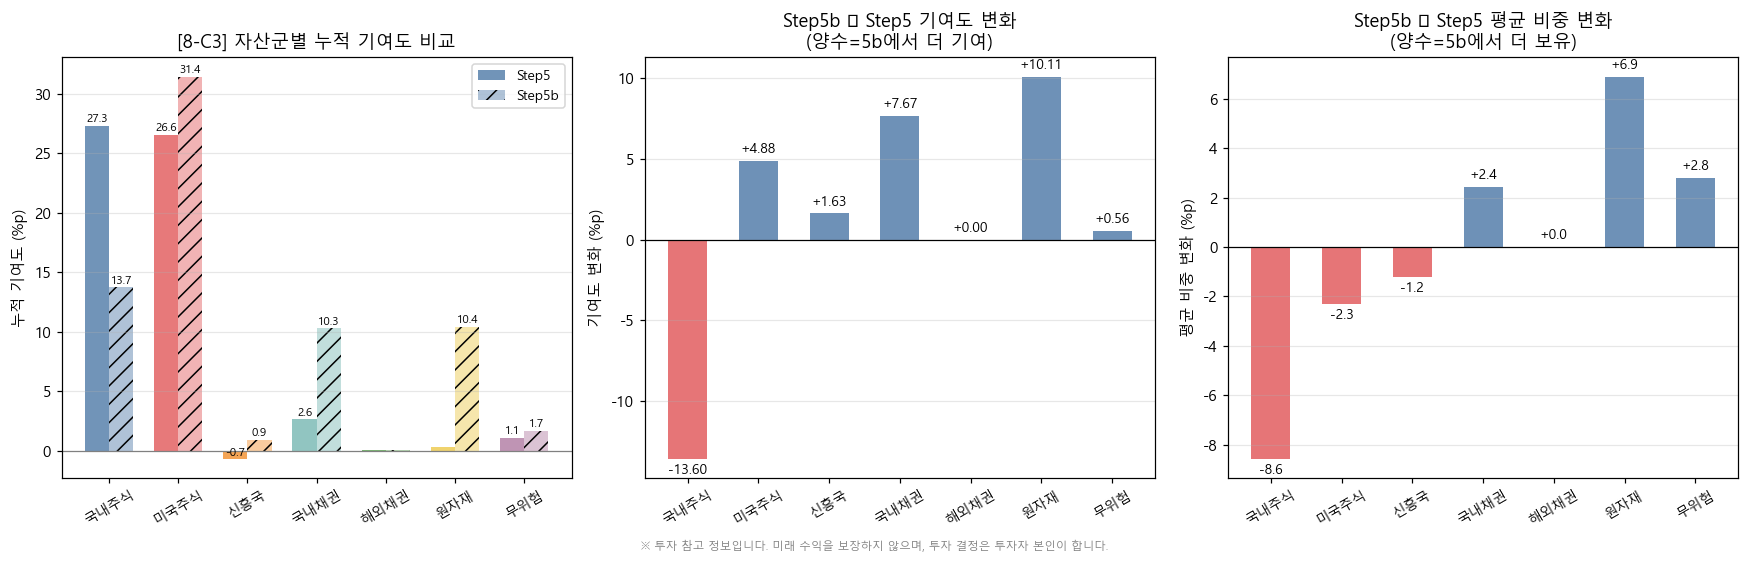


자산군별 누적 기여도 (Step5 vs Step5b):
그룹              Step5     Step5b       변화
국내주식           +27.32%p     +13.72%p   -13.60%p
미국주식           +26.56%p     +31.43%p    +4.88%p
신흥국             -0.73%p      +0.90%p    +1.63%p
국내채권            +2.61%p     +10.28%p    +7.67%p
해외채권            +0.06%p      +0.06%p    +0.00%p
원자재             +0.30%p     +10.41%p   +10.11%p
무위험             +1.09%p      +1.65%p    +0.56%p


In [9]:
# ── 8-C3: Step5 vs Step5b 성과 기여도 변화 ──
_SLOTS_GROUPED = {
    '국내주식': ['국내주식_코스피', '국내주식_코스닥'],
    '미국주식': ['미국주식_SP500',  '미국주식_나스닥'],
    '신흥국':   ['신흥국_인도',      '신흥국_중국'],
    '국내채권': ['국내채권_국고채단중기','국내채권_국고채장기',
                 '국내채권_회사채','국내채권_종합'],
    '해외채권': ['해외채권_미국국채'],
    '원자재':   ['원자재_금'],
    '무위험':   ['무위험(현금성)'],
}
_GROUP_COLORS = ['#4e79a7','#e15759','#f28e2b','#76b7b2','#59a14f','#edc948','#b07aa1']
_GROUP_MAP    = {s: g for g, slots in _SLOTS_GROUPED.items() for s in slots}
_GROUPS       = list(_SLOTS_GROUPED.keys())

# Step5 비중 (8-B4에서 계산한 w_con_df 재사용, 없으면 직접 로드)
try:
    _w5 = w_con_df
except NameError:
    _w5 = pd.read_parquet(S5_DIR / 'portfolio_weights_constrained.parquet')
    _w5.columns = SLOTS

def _calc_group_contrib(w_df):
    rebal = w_df.index.tolist()
    rows  = []
    for i, d in enumerate(rebal):
        end   = rebal[i+1] if i+1 < len(rebal) else idx_rets.index[-1]
        oos   = idx_rets.loc[d:end]
        w_row = w_df.loc[d]
        row   = {'date': d}
        for s in SLOTS:
            ret_s  = oos[s].dropna()
            real_q = float((1 + ret_s).prod() - 1) if len(ret_s) > 0 else 0.0
            row[s] = float(w_row.get(s, 0)) * real_q * 100
        rows.append(row)
    df = pd.DataFrame(rows).set_index('date')
    return pd.DataFrame({
        g: df[[s for s in SLOTS if _GROUP_MAP.get(s) == g]].sum(axis=1)
        for g in _GROUPS
    })

contrib_5  = _calc_group_contrib(_w5)
contrib_5b = _calc_group_contrib(w_5b)

total_5  = contrib_5.sum()
total_5b = contrib_5b.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 누적 기여도 비교 바
ax = axes[0]
x_g = np.arange(len(_GROUPS)); wg = 0.35
b1 = ax.bar(x_g - wg/2, [total_5.get(g, 0)  for g in _GROUPS], wg,
            label='Step5',  color=_GROUP_COLORS, alpha=0.80)
b2 = ax.bar(x_g + wg/2, [total_5b.get(g, 0) for g in _GROUPS], wg,
            label='Step5b', color=_GROUP_COLORS, alpha=0.45, hatch='//')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(x_g); ax.set_xticklabels(_GROUPS, rotation=30, fontsize=9)
ax.set_ylabel('누적 기여도 (%p)')
ax.set_title('[8-C3] 자산군별 누적 기여도 비교')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    v = bar.get_height()
    if abs(v) > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                f'{v:.1f}', ha='center', fontsize=7.5)

# 기여도 변화 (5b - 5)
ax2 = axes[1]
dc_vals   = [total_5b.get(g, 0) - total_5.get(g, 0) for g in _GROUPS]
dc_colors = ['#4e79a7' if v >= 0 else '#e15759' for v in dc_vals]
bars = ax2.bar(x_g, dc_vals, color=dc_colors, alpha=0.82, width=0.55)
ax2.bar_label(bars, fmt='%+.2f', padding=3, fontsize=9)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x_g); ax2.set_xticklabels(_GROUPS, rotation=30, fontsize=9)
ax2.set_ylabel('기여도 변화 (%p)')
ax2.set_title('Step5b − Step5 기여도 변화\n(양수=5b에서 더 기여)')
ax2.grid(axis='y', alpha=0.3)

# 평균 비중 변화
ax3 = axes[2]
avg_w5  = (_w5 * 100).mean()
avg_w5b = (w_5b * 100).mean()
grp_w5  = {g: sum(avg_w5.get(s, 0)  for s in slots) for g, slots in _SLOTS_GROUPED.items()}
grp_w5b = {g: sum(avg_w5b.get(s, 0) for s in slots) for g, slots in _SLOTS_GROUPED.items()}
dw        = [grp_w5b[g] - grp_w5[g] for g in _GROUPS]
dw_colors = ['#4e79a7' if v >= 0 else '#e15759' for v in dw]
bars2 = ax3.bar(x_g, dw, color=dw_colors, alpha=0.82, width=0.55)
ax3.bar_label(bars2, fmt='%+.1f', padding=3, fontsize=9)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x_g); ax3.set_xticklabels(_GROUPS, rotation=30, fontsize=9)
ax3.set_ylabel('평균 비중 변화 (%p)')
ax3.set_title('Step5b − Step5 평균 비중 변화\n(양수=5b에서 더 보유)')
ax3.grid(axis='y', alpha=0.3)

fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

print('\n자산군별 누적 기여도 (Step5 vs Step5b):')
print(f"{'그룹':<10} {'Step5':>10} {'Step5b':>10} {'변화':>8}")
for g in _GROUPS:
    v5  = total_5.get(g, 0)
    v5b = total_5b.get(g, 0)
    print(f'{g:<10} {v5:>+10.2f}%p {v5b:>+10.2f}%p {v5b-v5:>+8.2f}%p')

---
## 8-D 베이스라인 비교: 방치된 포트폴리오 vs 최적화 전략

퇴직연금을 아무 전략 없이 유지했을 때와 최적화 전략의 차이를 정량화합니다.

| 베이스라인 | 의미 |
|---|---|
| **무위험 100%** | 원리금보장형 상품만 유지 (가장 흔한 방치 패턴) |
| **동일비중 (1/N)** | 전체 슬롯 균등 투자, 분기 리밸런싱 |
| **시장비중 (AUM)** | 국내 퇴직연금 AUM 비중대로 보유 |
| **코스피 100%** | 국내 주식 단일 집중 투자 |

> **Step5b (B+C)** 와 직접 비교해 최적화의 실질 가치를 확인합니다.

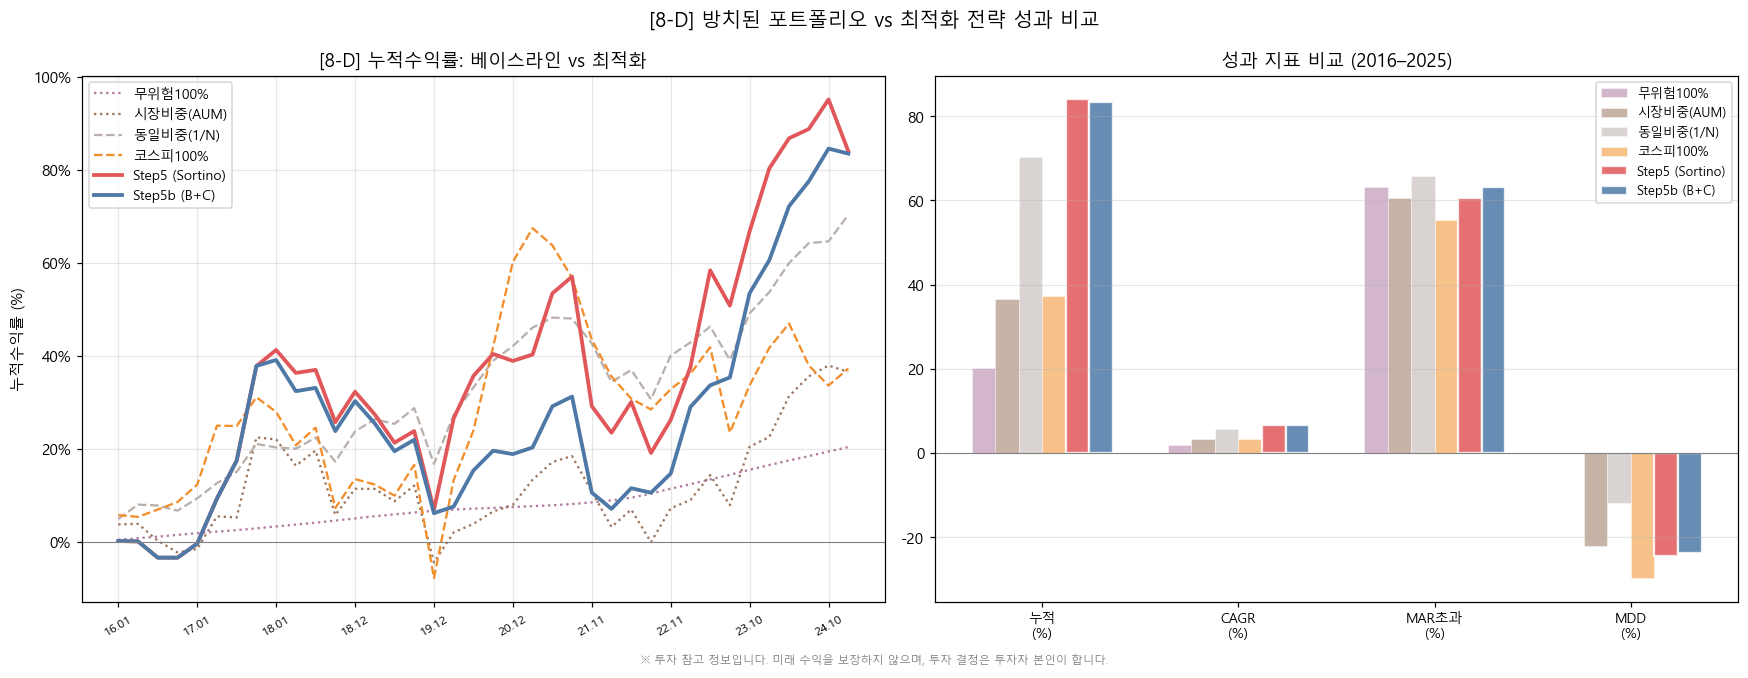

전략                       누적    CAGR    MAR초과      MDD
------------------------------------------------------
무위험100%               20.3%   1.97%    63.2%    0.00%
시장비중(AUM)             36.5%   3.33%    60.5%  -22.00%
동일비중(1/N)             70.3%   5.76%    65.8%  -11.86%
코스피100%               37.2%   3.39%    55.3%  -29.69%
Step5 (Sortino)       84.0%   6.63%    60.5%  -24.35%
Step5b (B+C)          83.4%   6.60%    63.2%  -23.70% ◀


In [10]:
# ── 8-D: 베이스라인 vs 최적화 전략 비교 ──
RF_SLOT     = '무위험(현금성)'
mar_monthly = pd.read_parquet(ROOT / 'data' / 'mar_series.parquet')['mar_annual']
mar_daily   = mar_monthly.resample('D').ffill().reindex(idx_rets.index).ffill().bfill() / 100

yeb = pd.read_csv(ROOT / 'data' / 'year_end_best.csv')
aum_by_year = {}
for yr, grp in yeb.groupby('year'):
    aum_by_year[int(yr)] = dict(zip(grp['slot'], grp['aum_억'].astype(float)))

rebal_dates = perf_con.index.tolist()
mar_q_arr   = (perf_con['mar_annual_pct'] / 4).values

bl_rows = {'date': [], 'eq_ret': [], 'rf_ret': [], 'mktcap_ret': [], 'kospi_ret': []}
for i, d in enumerate(rebal_dates):
    end   = rebal_dates[i+1] if i+1 < len(rebal_dates) else idx_rets.index[-1]
    oos   = idx_rets.loc[d:end]
    valid = [s for s in SLOTS if oos[s].dropna().__len__() > 5]

    # 동일비중
    w_eq  = 1.0 / len(valid)
    eq_q  = sum(float((1+oos[s].dropna()).prod()-1)*w_eq for s in valid)*100

    # 무위험 100%
    rf_q  = float((1+oos[RF_SLOT].dropna()).prod()-1)*100

    # 시장비중 (AUM)
    ref_yr = d.year - 1
    if ref_yr not in aum_by_year:
        ref_yr = max(k for k in aum_by_year if k <= d.year)
    aum_d     = aum_by_year[ref_yr]
    valid_aum = [s for s in valid if s in aum_d]
    tot_aum   = sum(aum_d[s] for s in valid_aum)
    mkt_q     = sum(float((1+oos[s].dropna()).prod()-1)*aum_d[s]/tot_aum for s in valid_aum)*100

    # 코스피 100%
    kos_q = float((1+oos['국내주식_코스피'].dropna()).prod()-1)*100

    bl_rows['date'].append(d); bl_rows['eq_ret'].append(eq_q)
    bl_rows['rf_ret'].append(rf_q); bl_rows['mktcap_ret'].append(mkt_q)
    bl_rows['kospi_ret'].append(kos_q)

base_df = pd.DataFrame(bl_rows).set_index('date')

# ── 누적 수익 계산 ──
def cum_series(ret_arr):
    return (1 + np.array(ret_arr)/100).cumprod()

def perf_stats(ret_arr):
    c = cum_series(ret_arr)
    mdd  = ((c - np.maximum.accumulate(c)) / np.maximum.accumulate(c)).min()*100
    cagr = (c[-1]**(4/len(c))-1)*100
    mar_beat = (np.array(ret_arr) >= mar_q_arr).mean()*100
    return {'누적':(c[-1]-1)*100, 'CAGR':cagr, 'MAR초과':mar_beat, 'MDD':mdd}

STRATEGIES = {
    '무위험100%':    base_df['rf_ret'].values,
    '시장비중(AUM)': base_df['mktcap_ret'].values,
    '동일비중(1/N)': base_df['eq_ret'].values,
    '코스피100%':    base_df['kospi_ret'].values,
    'Step5 (Sortino)': perf_con['cum_ret_pct'].values,
    'Step5b (B+C)':    perf_5b['cum_ret_pct'].values,
}
COLORS = {
    '무위험100%':    '#b07aa1',
    '시장비중(AUM)': '#9c755f',
    '동일비중(1/N)': '#bab0ac',
    '코스피100%':    '#f28e2b',
    'Step5 (Sortino)': '#e15759',
    'Step5b (B+C)':    '#4e79a7',
}
STYLES = {
    '무위험100%':    ':',
    '시장비중(AUM)': ':',
    '동일비중(1/N)': '--',
    '코스피100%':    '--',
    'Step5 (Sortino)': '-',
    'Step5b (B+C)':    '-',
}
x_q    = np.arange(len(rebal_dates))
xlbl_q = [d.strftime('%y.%m') for d in rebal_dates]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 누적수익률 시계열 ──
ax = axes[0]
for name, ret in STRATEGIES.items():
    c = (cum_series(ret) - 1)*100
    lw = 2.5 if 'Step5' in name else 1.5
    ax.plot(x_q, c, ls=STYLES[name], color=COLORS[name], lw=lw, label=name)
ax.axhline(0, color='gray', lw=0.7)
ax.set_xticks(x_q[::4]); ax.set_xticklabels(xlbl_q[::4], rotation=30, fontsize=8)
ax.set_ylabel('누적수익률 (%)')
ax.set_title('[8-D] 누적수익률: 베이스라인 vs 최적화')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))

# ── 성과 지표 비교 바 ──
ax2 = axes[1]
stat_names = ['누적\n(%)', 'CAGR\n(%)', 'MAR초과\n(%)', 'MDD\n(%)']
n_strat = len(STRATEGIES)
x_m = np.arange(len(stat_names))
bar_w = 0.12
offsets = np.linspace(-(n_strat-1)/2, (n_strat-1)/2, n_strat) * bar_w

for i, (name, ret) in enumerate(STRATEGIES.items()):
    s = perf_stats(ret)
    vals = [s['누적'], s['CAGR'], s['MAR초과'], s['MDD']]
    bars = ax2.bar(x_m + offsets[i], vals, bar_w,
                   label=name, color=COLORS[name],
                   alpha=0.85 if 'Step5' in name else 0.55,
                   lw=1.5 if 'Step5' in name else 0.5,
                   edgecolor='white')

ax2.axhline(0, color='gray', lw=0.7)
ax2.set_xticks(x_m); ax2.set_xticklabels(stat_names, fontsize=9)
ax2.set_title('성과 지표 비교 (2016–2025)')
ax2.legend(fontsize=8.5, loc='upper right'); ax2.grid(axis='y', alpha=0.3)

fig.suptitle('[8-D] 방치된 포트폴리오 vs 최적화 전략 성과 비교', fontsize=13)
fig.text(0.5, -0.01, DISCLAIMER, ha='center', fontsize=7.5, color='gray', style='italic')
plt.tight_layout(); plt.show()

# ── 수치 요약 ──
print(f"{'전략':<18} {'누적':>8} {'CAGR':>7} {'MAR초과':>8} {'MDD':>8}")
print('-'*54)
for name, ret in STRATEGIES.items():
    s = perf_stats(ret)
    marker = ' ◀' if 'Step5b' in name else ''
    print(f"{name:<18} {s['누적']:>7.1f}% {s['CAGR']:>6.2f}% {s['MAR초과']:>7.1f}% {s['MDD']:>7.2f}%{marker}")